In [1]:
import sys
sys.path.insert(0, "../..")

from src.models        import build_logdeeponet
from src.data          import ODEIterableDataset, DirichletSampler, ConstrainedLHCSampler
from src.physics       import Robertson, ODEsolver
from src.training      import Trainer, build_dataloaders

import numpy as np
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
})

colors = ["red", "darkviolet", "deepskyblue"]
cmap   = LinearSegmentedColormap.from_list("high_contrast", colors)

In [2]:
# Initialize Roberston Model
k1 = 4e-2
k2 = 3e7
k3 = 1e4
system = Robertson([k1, k2, k3])

# Initialize Sampler Object 
sampler = ConstrainedLHCSampler(low=0.5, high=1.0)

# Initialize Solver
solver = ODEsolver(system).solve

In [3]:
dataset_size = 1000
batch_size   = 1
num_workers  = 0
t_final      = 1e6
t_span       = (1e-4, t_final)

rob_dataset = ODEIterableDataset(size          = dataset_size,
                                 system_class  = system,
                                 sampler       = sampler,
                                 t_span        = t_span,
                                 log_sampling  = False,
                                 full_solution = True,
                                 method        = "BDF")

rob_loader  = DataLoader(dataset     = rob_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)

In [4]:
# Set Up DeepONet configuration 


DEEPONET_CONFIG = {
    
    "hidden_size" : 128,
    "depth"       : 4,
    "latent_size" : 120,
    "input_size_b": 3,
    "input_size_t": 1,
    "output_size" : 3,
    "activation"  : "gelu",
    "t_span"      : t_span

}

# Initialize DeepONet network
 
deeponet = build_logdeeponet(DEEPONET_CONFIG).to(device)
deeponet.load_state_dict(torch.load("../../weights/best_robertson.pth", map_location=device))
deeponet.eval()

_ = 0

In [9]:
from src.benchmark import trajectory 

ts, sols, preds = [], [], []

for i in range(4):
    t, sol, pred = trajectory(deeponet, rob_loader, device)
    ts.append(t)
    sols.append(sol)
    preds.append(pred)

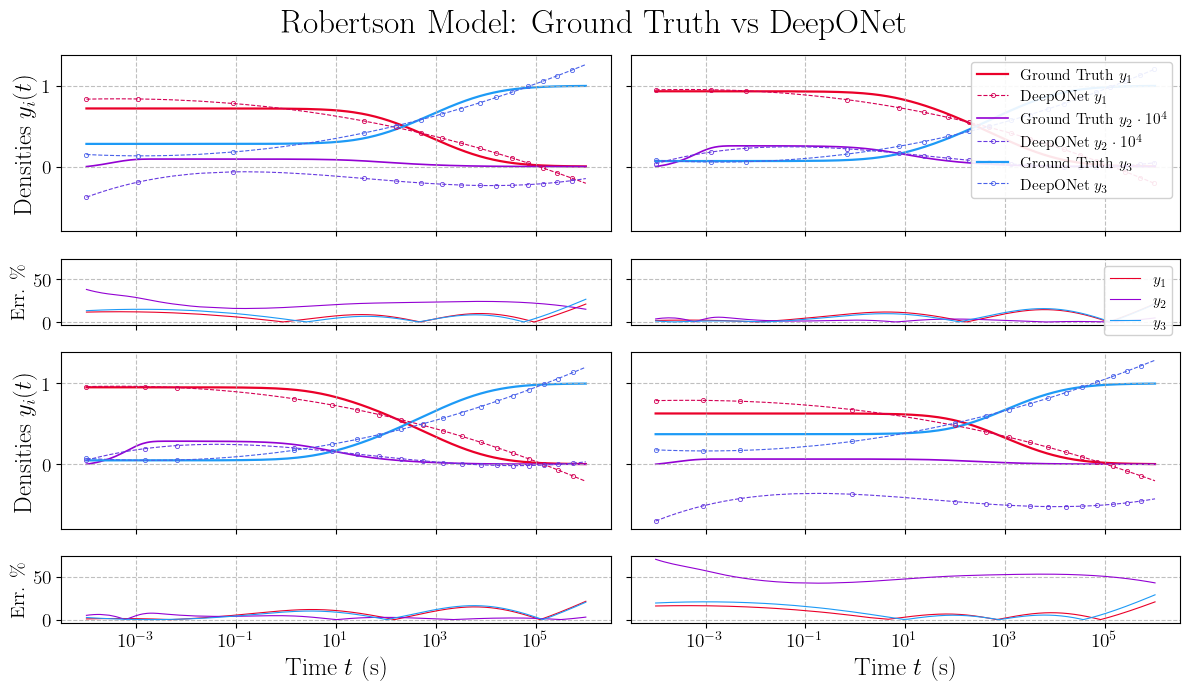

In [ ]:

fig, axs = plt.subplots(4, 2, figsize=(12, 7),
                        sharex=True,
                        sharey=False,
                        gridspec_kw={"height_ratios": [4, 1.5, 4, 1.5]})

# Residuals need to share y axis
for ax in axs[::2, :].flatten()[1:]:
    ax.sharey(axs[0, 0])

# Share residual axes together
for ax in axs[1::2, :].flatten()[1:]:
    ax.sharey(axs[1, 0])

gt_color   = [cmap(0.1), cmap(0.5), cmap(0.9)]
pred_color = [cmap(0.2), cmap(0.65), cmap(0.75)]

for i in range(4):

    row  = (i // 2) * 2 # This is 0 for i = 0, 1 and 2 for i = 2, 3
    col  = i % 2        # This is either 0, 1

    # Separate main plots from residuals 
    ax_main  = axs[row,     col]
    ax_res   = axs[row + 1, col] # sum one to be plotting in residuals

    residuals = []
    # Main Plots
    for j in range(3):

        if j % 2 == 0: # is 0 for j = 0 and j = 2 for species y_1 and y_3
            ax_main.plot(ts[i], 
                        sols[i][j],     
                        color  = gt_color[j],   
                        lw     = 1.6, 
                        label  = rf"Ground Truth $y_{j+1}$",
                        zorder = 1)
            
            ax_main.plot(ts[i], preds[i][:, j],
                        color            = pred_color[j],
                        lw               = 0.8,
                        label            = rf"DeepONet $y_{{{j+1}}}$",
                        linestyle        = "--",
                        marker           = 'o',
                        markersize       = 3,
                        markerfacecolor  = 'none',
                        markeredgecolor  = pred_color[j],
                        markeredgewidth  = 0.6,
                        markevery        = 20) 

            
            residuals.append(np.abs((sols[i][j] - preds[i][:, j]))* 100)
        
        else: # This is for species y_2
            ax_main.plot(ts[i], 
                        sols[i][j] * 10**4,     
                        color  = gt_color[j],   
                        lw     = 1.2, 
                        label  = fr"Ground Truth $y_{j+1} \cdot 10^4$",
                        zorder = 1)
            
            ax_main.plot(ts[i], 
                        preds[i][:, j] * 10**4, 
                        color            = pred_color[j],
                        lw               = 0.8,
                        label            = rf"DeepONet $y_{{{j+1}}} \cdot 10^4$",
                        linestyle        = "--",
                        marker           = 'o',
                        markersize       = 3,
                        markerfacecolor  = 'none',
                        markeredgecolor  = pred_color[j],
                        markeredgewidth  = 0.6,
                        markevery        = 20) 
            
            residuals.append(np.abs((sols[i][j] - preds[i][:, j])*10**4)* 100)

    # Residual Plots
    ax_main.set_xscale("log")
    ax_main.grid(linestyle="--", alpha=0.8)
    ax_main.tick_params(axis='both', labelsize=14)

    # Residual Plots
    for j in range(3):
        ax_res.plot(ts[i], residuals[j],
            color=gt_color[j], lw=0.8,
            label=rf"$y_{j+1}$")

    ax_res.set_xscale("log")
    ax_res.grid(linestyle="--", alpha=0.8)
    ax_res.tick_params(axis='both', labelsize=14)


axs[1, 1].legend(fontsize=11, framealpha=0.9,  loc="upper right")    
axs[0, 1].legend(fontsize=11, framealpha=0.9, loc="upper right")

for ax in axs[-1, :]:
    ax.set_xlabel("Time $t$ (s)", fontsize=18, color="black")
for ax in axs[::2, 0]:                  # main rows, left column
    ax.set_ylabel(r"Densities $y_i(t)$", fontsize=18, color="black")
for ax in axs[1::2, 0]:                 # residual rows, left column
    ax.set_ylabel(r"Err. $\%$", fontsize=14, color="black")

# Hide y tick labels on right column
for ax in axs[:, 1]:
    ax.tick_params(labelleft=False)


fig.suptitle("Robertson Model: Ground Truth vs DeepONet", fontsize=24, color="black")
plt.tight_layout()
# plt.savefig("robertson_prediction.png", dpi=200, bbox_inches="tight")
plt.show()

In [7]:
# Set the full solution of the dataset back to false 

rob_dataset.full_solution = False
rob_dataset.log_sampling  = True

rob_loader  = DataLoader(dataset     = rob_dataset,
                         batch_size  = batch_size,
                         num_workers = num_workers)

In [8]:
from src.benchmark import trajectory 

ts, sols, preds = [], [], []

for i in range(5000):
    t, sol, pred = trajectory(deeponet, rob_loader, device)
    ts.append(t)
    sols.append(sol)
    preds.append(pred)

In [9]:
preds_arr = np.array(preds)[:, 0] 
sols_arr  = np.array(sols)  

scale = np.abs(sols_arr).max() - np.abs(sols_arr).min()

percentage_error = np.mean(np.abs(preds_arr - sols_arr) / scale) * 100
print(f"NRMSE: {percentage_error:.2f}%")

NRMSE: 5.49%


In [10]:
from src.benchmark import timing_data

num_boxes   = 10
num_samples = 100
t_final     = 1e6

nn_timing, solver_timing = timing_data(model       = deeponet, 
                                       ODEsolver   = solver, 
                                       sampler     = sampler,
                                       t_final     = t_final, 
                                       num_samples = num_samples,
                                       num_boxes   = num_boxes, 
                                       method      = "BDF",
                                       device      = device)

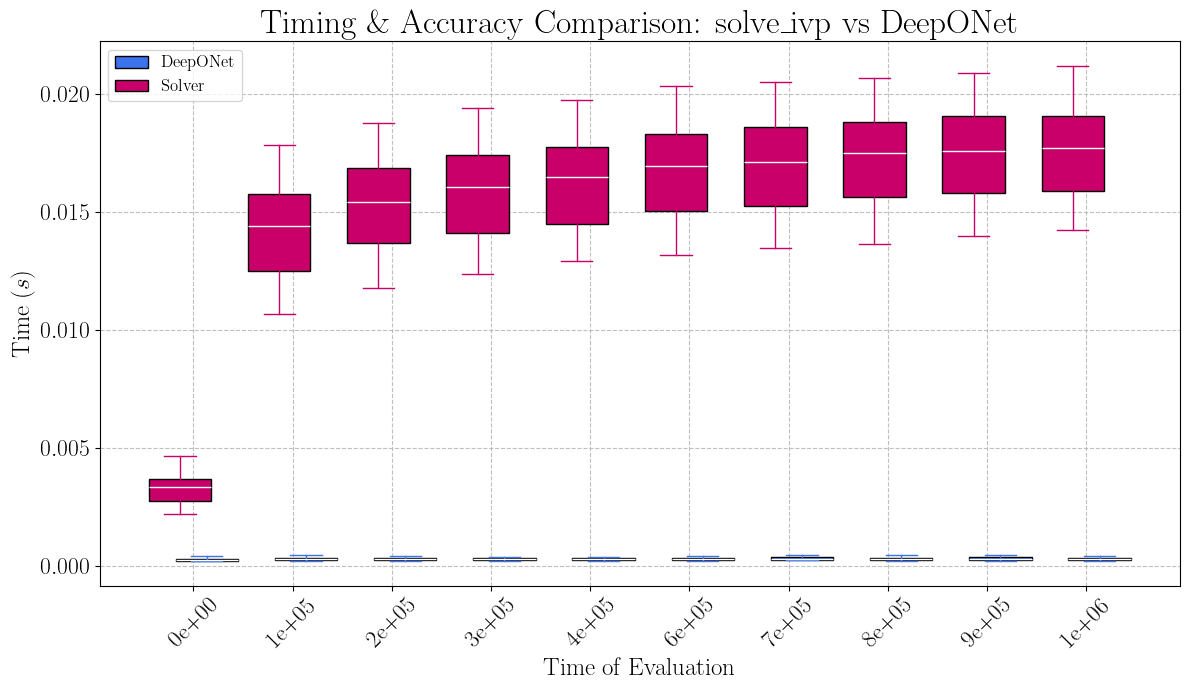

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

solver_color = cmap(0.25)
nn_color     = cmap(0.8)

ax.boxplot(nn_timing, 
           positions    = np.linspace(0, t_final, num_boxes) + 0.15e5,
           widths       = 0.70e5, 
           patch_artist = True,
           showfliers   = False, 
           boxprops     = dict(facecolor=nn_color, color="black"),
           medianprops  = dict(color="white"),
           whiskerprops = dict(color=nn_color),
           capprops     = dict(color=nn_color),
           label        = "DeepONet")

ax.boxplot(solver_timing,
           positions    = np.linspace(0, t_final, num_boxes) - 0.15e5,
           widths       = 0.70e5,
           patch_artist = True,
           showfliers   = False,
           boxprops     = dict(facecolor=solver_color, color="black"),
           medianprops  = dict(color="white"),
           whiskerprops = dict(color=solver_color),
           capprops     = dict(color=solver_color),
           label        = "Solver")
                

ax.set_xticks(np.arange(num_boxes))
tick_positions = np.linspace(0, t_final, num_boxes)
ax.set_xticks(tick_positions)
ax.set_xticklabels([f"{t:.0e}" for t in tick_positions], rotation=45)

ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel(r"Time of Evaluation",           fontsize=18, color="black")
ax.set_ylabel(r"Time ($s$)",                   fontsize=18, color="black")
ax.set_title(r"Timing \& Accuracy Comparison: solve\_ivp vs DeepONet", fontsize=24, color="black")
ax.legend(fontsize=14)
ax.grid(linestyle="--", alpha=0.8)
ax.legend(fontsize=12)
ax.tick_params(axis='both', labelsize=17) 


plt.tight_layout()
# plt.savefig("timing_comparison_rob.png", dpi=200, bbox_inches="tight")
plt.show()

In [12]:
rob_loader  = DataLoader(dataset     = rob_dataset,
                         batch_size  = batch_size,
                         num_workers = 12)

In [13]:
from src.benchmark import semigroup_data

loss_fn     = torch.nn.MSELoss()
num_samples = 1000
num_boxes   = 20

loss_direct, loss_2step, loss_3step, sol_norms = semigroup_data(model       = deeponet, 
                                                                ODEsolver   = solver, 
                                                                sampler     = sampler,
                                                                loss_fn     = loss_fn,
                                                                t_final     = t_final, 
                                                                num_samples = num_samples, 
                                                                num_boxes   = num_boxes, 
                                                                out_mask    = None,
                                                                device      = device,
                                                                method      = "BDF")

In [14]:
loss_direct = np.array(loss_direct)  
loss_2step  = np.array(loss_2step)
loss_3step  = np.array(loss_3step)
sol_norms   = np.array(sol_norms)    

truth_means = np.mean(sol_norms, axis=1) 

# Normalize across 
pct_error_1 = np.mean(loss_direct, axis=1)  * 100
pct_error_2 = np.mean(loss_2step,  axis=1)  * 100
pct_error_3 = np.mean(loss_3step,  axis=1) * 100

# Normalize for box plotting ([:, None] changes shape from (N,) to (N, 1))
pct_direct = (loss_direct) * 100 
pct_2step  = (loss_2step) * 100
pct_3step  = (loss_3step) * 100

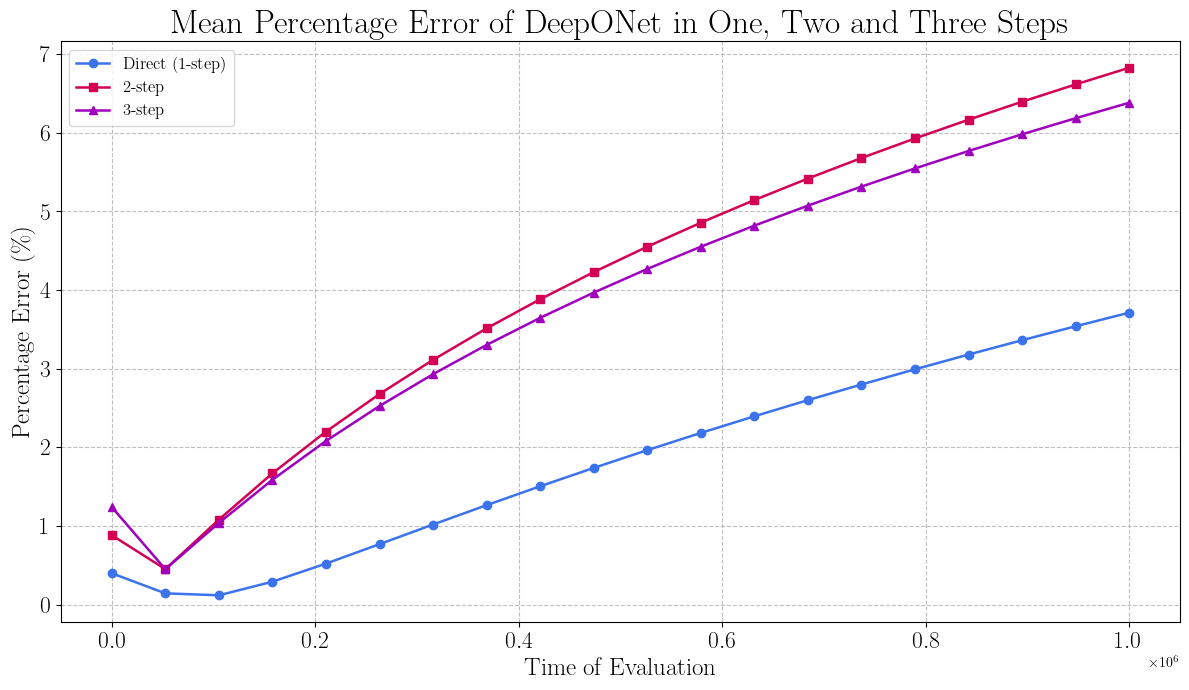

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

color_gt   = cmap(0.8)   # Yellow/Orange
color_pred = cmap(0.2)   # Purple
color_res  = cmap(0.45)  # Reddish

series = [
    (pct_error_1, 'o', 'Direct (1-step)', color_gt),
    (pct_error_2, 's', '2-step',          color_pred),
    (pct_error_3, '^', '3-step',          color_res),
]

for means, marker, label, color in series:
    ax.plot(np.linspace(0, t_final, num_boxes), 
            means, marker=marker, label=label,
            color=color, linewidth=1.8, alpha=1.0)

ax.grid(linestyle='--', alpha=0.8)
ax.legend(fontsize=12)
ax.set_xlabel(r"Time of Evaluation",                    fontsize=18, color="black")
ax.set_ylabel(r"Percentage Error (\%)",                 fontsize=18, color="black")
ax.set_title(r"Mean Percentage Error of DeepONet in One, Two and Three Steps", fontsize=24, color="black")
ax.tick_params(axis='both', labelsize=17) 
plt.tight_layout()
# plt.savefig("rob_mean_loss_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

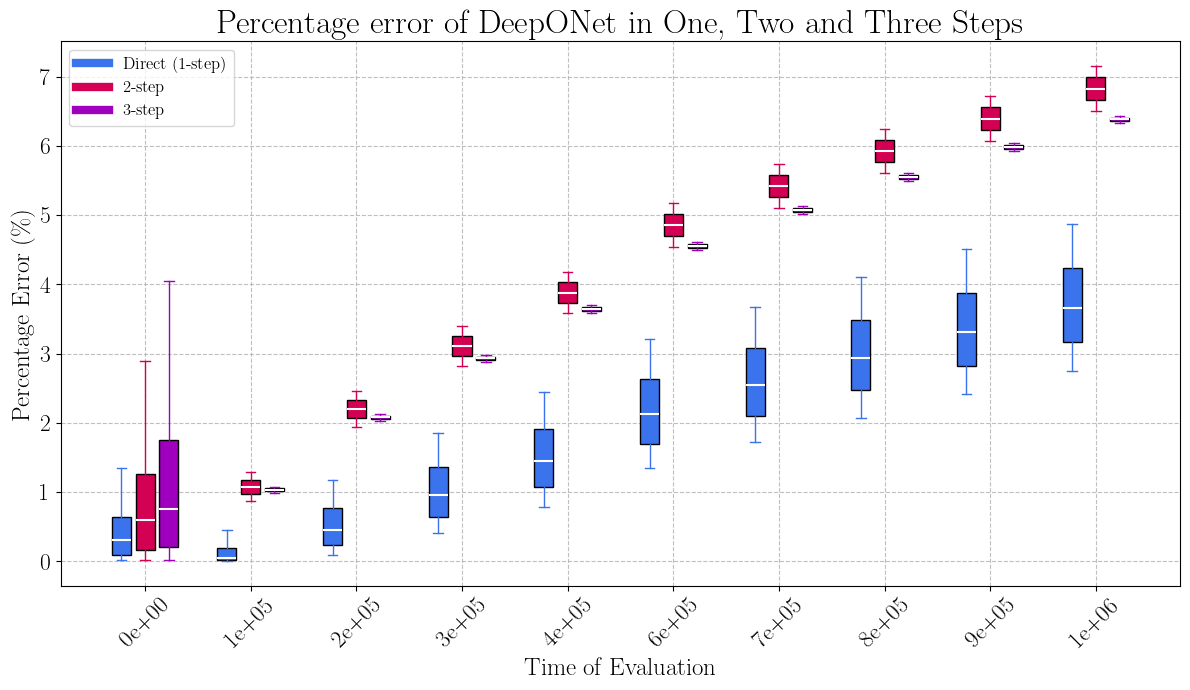

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))

color_gt   = cmap(0.8)
color_pred = cmap(0.2)
color_res  = cmap(0.45)

n = 10
idx = np.round(np.linspace(0, len(pct_direct) - 1, n)).astype(int)

datasets = [
    [pct_direct[i] for i in idx],
    [pct_2step[i]  for i in idx],
    [pct_3step[i]  for i in idx],
]

labels   = ['Direct (1-step)', '2-step', '3-step']
colors   = [color_gt, color_pred, color_res]
offsets  = [-0.25e5, 0.0, 0.25e5]

for data, offset, color, label in zip(datasets, offsets, colors, labels):
    bp = ax.boxplot(
        data,
        positions    = np.linspace(0, t_final, n) + offset,
        widths       = 0.2e5,
        patch_artist = True,
        showfliers   = False,
        medianprops  = dict(color="white", linewidth=1.5),
    )
    
    for box in bp['boxes']:
        box.set_facecolor(color)
    
    for element in ['whiskers', 'caps']:
        for line in bp[element]:
            line.set_color(color)
    
    ax.plot([], [], color=color, linewidth=6, label=label)

ax.set_xticks(np.arange(n))
tick_positions = np.linspace(0, t_final, n)
ax.set_xticks(tick_positions)
ax.set_xticklabels([f"{t:.0e}" for t in tick_positions], rotation=45)

ax.grid(linestyle='--', alpha=0.8)
ax.legend(fontsize=12)
ax.set_xlabel("Time of Evaluation", fontsize=18, color="black")
ax.set_ylabel(r"Percentage Error (\%)",        fontsize=18, color="black")
ax.set_title(r"Percentage error of DeepONet in One, Two and Three Steps", fontsize=24, color="black")
ax.tick_params(axis='both', labelsize=17) 
plt.tight_layout()
# plt.savefig("rob_boxplot_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

In [17]:
import wandb

api = wandb.Api()
sweep = api.sweep("nikpursals/robertson-3-sweep/h1zamc4n")
runs = sweep.runs

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/enricp/.netrc.


In [18]:
run_data = []
for run in runs:
    history  = run.history(keys=["val_loss"], pandas=False)
    val_loss = [row["val_loss"] for row in history if "val_loss" in row]
    log_loss = np.log(val_loss)
    run_data.append((log_loss, log_loss[-1]))

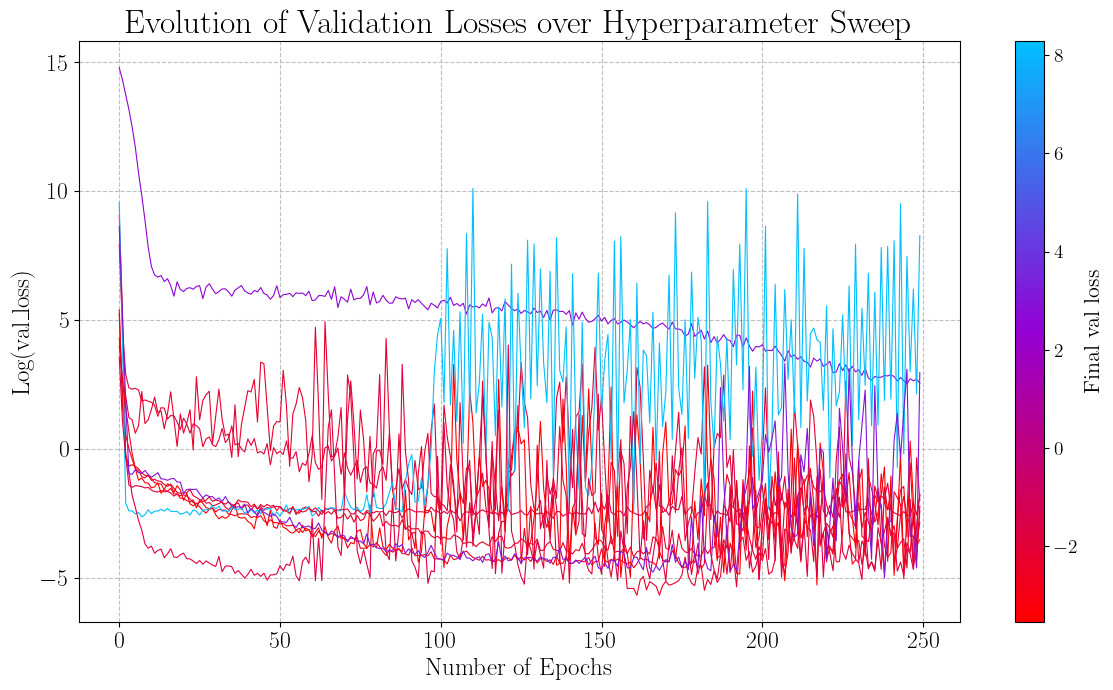

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

finals = [run[1] for run in run_data]
vmin, vmax = min(finals), max(finals)
norm = plt.Normalize(vmin, vmax)


for run in run_data:
    ax.plot(run[0], color=cmap(norm(run[1])), linewidth=0.8, alpha=1.0)


sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label="Final val loss")
cbar.ax.tick_params(labelsize=14)
cbar.set_label("Final val loss", fontsize=16)


ax.grid(linestyle="--", alpha=0.8)
ax.set_xlabel("Number of Epochs", fontsize=18, color="black")
ax.set_ylabel("Log(val_loss)", fontsize=18,  color="black")
ax.set_title("Evolution of Validation Losses over Hyperparameter Sweep", fontsize=24,  color="black")
ax.tick_params(axis='both', labelsize=17) 

plt.tight_layout()
# plt.savefig("val_loss_rob.png", dpi=200, bbox_inches="tight")
plt.show()